In [1]:
import re
import numpy as np
import assembly_pool as ap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from tqdm import tqdm

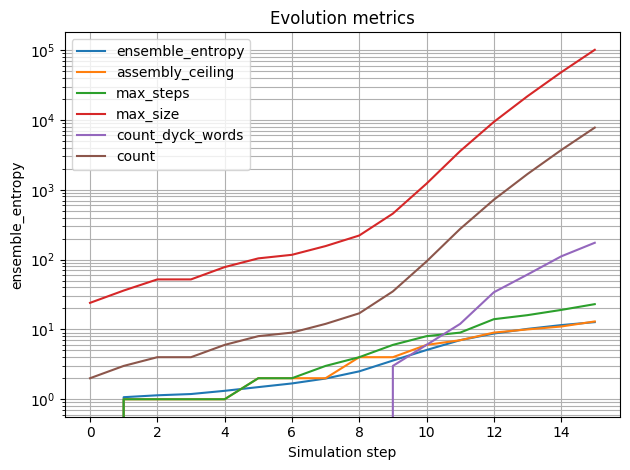

In [3]:
ap.evol_graph(evolution)

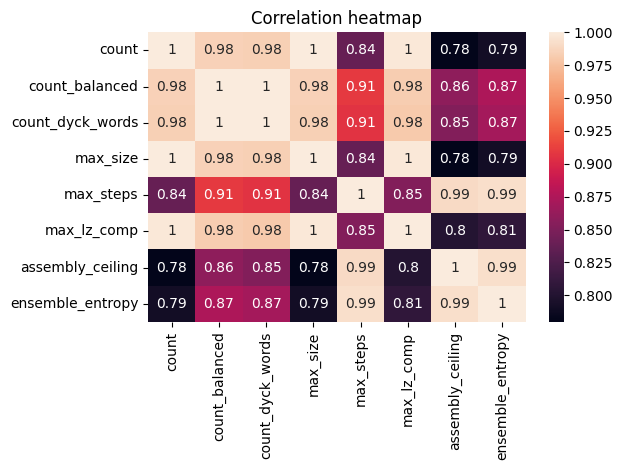

In [4]:
sns.heatmap(evolution.corr(),annot=True)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [51]:
a.pool['size'] = a.pool.element.str.len() 
a.pool['balanced'] = np.abs(a.pool.element.str.count("0") - a.pool.element.str.count("1"))<= 1

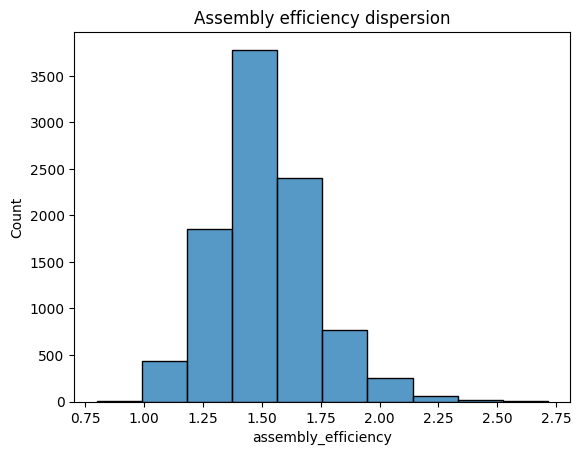

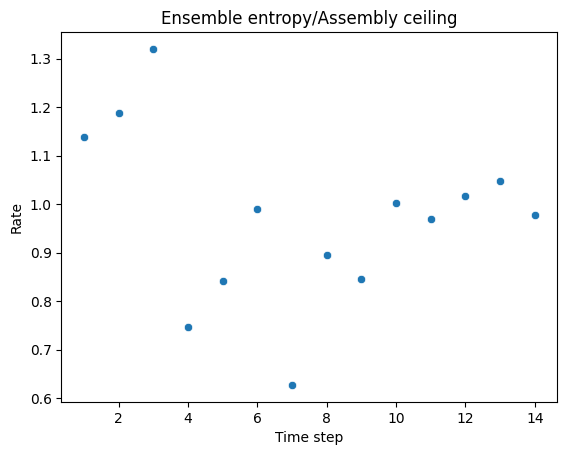

In [53]:
rate = evolution.ensemble_entropy/evolution.assembly_ceiling
sns.scatterplot(x =evolution.index,y = rate)
plt.title("Ensemble entropy/Assembly ceiling")
plt.xlabel("Time step")
plt.ylabel("Rate")
plt.show()

In [10]:
a.pool[a.pool.assembly_efficiency < 1]

,element,copy_number,size,balanced,dyck_word,entropy,assembly,assembly_efficiency,history,steps,lz_comp,has_inversion,ensemble
269,00101100011,1,11,True,False,0.99403,5,0.8,(((((0)(0))((1)(0)))((1)(1)))((((0)(0))(0))((1...,4,4,False,0.000117
604,00011100011,1,11,True,False,0.99403,5,0.8,(((((0)(0))(0))(((1)(1))(1)))((((0)(0))(0))((1...,4,5,False,0.000117


/tmp/ipykernel_243613/2284177951.py:12: RuntimeWarning: invalid value encountered in log
  return a * np.log(b*x) + c


[ 1.39373764  0.14338528 -0.35922477]


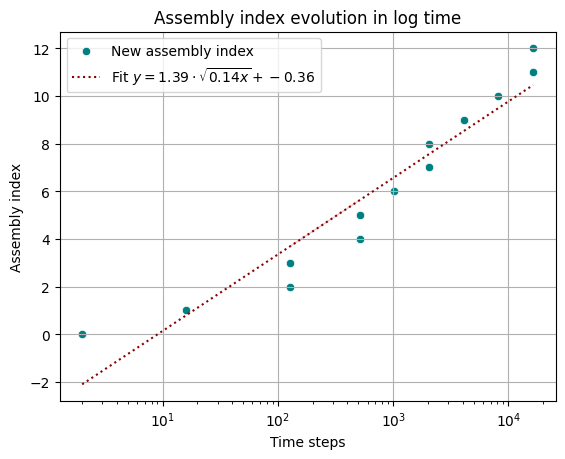

In [58]:
data = np.zeros([np.max(evolution.assembly_ceiling),2])
for i in range(np.max(evolution.assembly_ceiling)):
    tk = np.min(evolution[evolution.assembly_ceiling > i].index)

    data[i,0] = tk
    data[i,1] = i

x = np.power(2,data[:,0])
y = data[:,1]

def func(x,a,b,c):
    return a * np.log(b*x) + c

popt, pcov = curve_fit(func, x, y)
print(popt)
sns.scatterplot(x = x, y = y,color="teal" , label="New assembly index")
sns.lineplot(x=x, y=func(x, *popt),color="darkred",linestyle=":",label=fr"Fit $y ={np.round(popt[0],2)}\cdot\sqrt{{{np.round(popt[1],2)}x}}+{np.round(popt[2],2)}$")
plt.title("Assembly index evolution in log time")
plt.xlabel("Time steps")
plt.ylabel("Assembly index")
plt.xscale("log")
plt.grid(which="major")
plt.legend()
plt.show()


| n0 = n1 = N/2 | Time steps    |exponent               |
|----------     |----------     |---------              |
| 1             | 1000          | 3.46 x log(3.9x)      |
| 5             | 1000          | 3.04 x log(0.7x)      |
| 10            | 1000          | 2.31 x log(0.43x)     |
| 25            | 8000          | 2.14 x log(0.39x)     |
| 50            | 8000          | 2.01 x log(1.19x)     |
| 100           | 8000          | 1.72 x log(1.24x)     |
| 500           | 20000         | 1.35 x log(0.59x)     |
| 1000          | 20000         | 1.27 x log(2.93x)     |


In [ ]:
sims = 300
steps = 10000
evol_steps = 16
N =1000 
assemblies = np.zeros([sims,evol_steps])
entropies = np.zeros([sims,evol_steps])
steps_array = np.zeros([sims,evol_steps])
for i in range(sims):
   print(f"Iteration {i} of {sims}")
   a = ap.AssemblyPool(int(N/2),int(N/2))
   evolution = a.evolve(steps)
   assemblies[i,:] = evolution.assembly_ceiling
   entropies[i,:] = evolution.ensemble_entropy
   steps_array[i,:] = evolution.max_steps

entropy_df = pd.DataFrame(entropies,columns=range(evol_steps)).melt(var_name = "measurement", value_name="value")
assembly_df= pd.DataFrame(assemblies,columns=range(evol_steps)).melt(var_name = "measurement", value_name="value")
steps_df= pd.DataFrame(steps_array,columns=range(evol_steps)).melt(var_name = "measurement", value_name="value")

entropy_df.to_pickle(f"entropy_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
assembly_df.to_pickle(f"assembly_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
steps_df.to_pickle(f"steps_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")

# entropy_df = pd.read_pickle(f"entropy_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
# steps_df = pd.read_pickle(f"steps_df_s{sims}_n{N}_t{int(steps/1000)}k.pkl")
# assembly_df = pd.read_pickle(f"assembly_s{sims}_n{N}_t{int(steps/1000)}k.pkl")

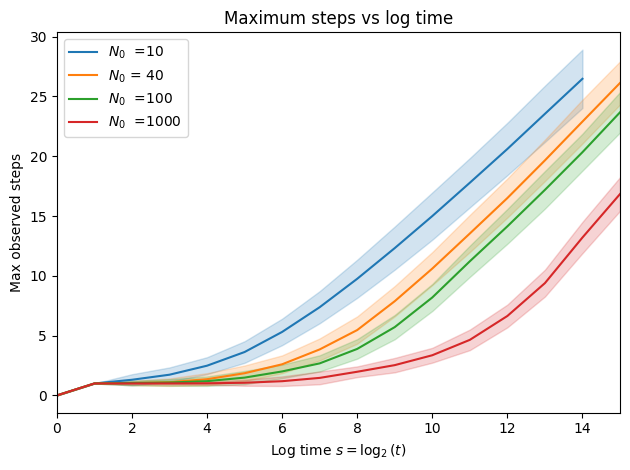

In [ ]:
steps_n4= pd.read_pickle("data/steps_df_s300_n4_t5k.pkl")
steps_n40 = pd.read_pickle("data/steps_df_s300_n40_t10k.pkl")
steps_n100= pd.read_pickle("data/steps_df_s300_n100_t10k.pkl")
steps_n1000= pd.read_pickle("data/steps_df_s300_n1000_t10k.pkl")

sns.lineplot(data=steps_n10, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =10")
sns.lineplot(data=steps_n40, x="measurement", y="value",errorbar="sd",label=r"$N_0$ = 40")
sns.lineplot(data=steps_n100, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =100")
sns.lineplot(data=steps_n1000, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =1000")
plt.title("Maximum steps vs log time")
plt.ylabel("Max observed steps")
plt.xlim([0,15])
plt.xlabel(r"Log time $s = \log_2(t)$")
plt.tight_layout()
plt.show()

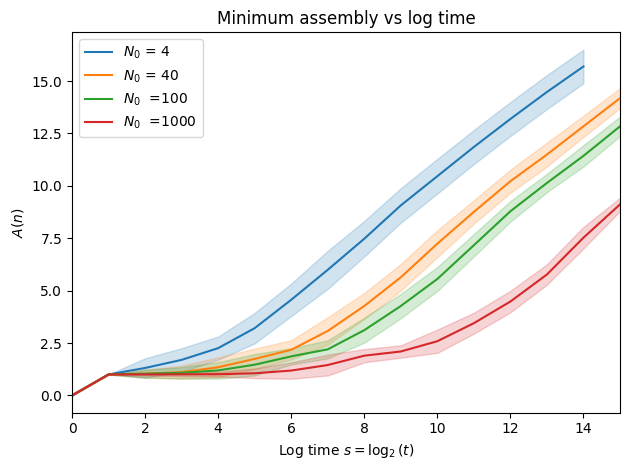

In [4]:
assembly_n4 = pd.read_pickle("data/assembly_df_s300_n4_t5k.pkl")
assembly_n40 = pd.read_pickle("data/assembly_df_s300_n40_t10k.pkl")
assembly_n100 = pd.read_pickle("data/assembly_df_s300_n100_t10k.pkl")
assembly_n1000 = pd.read_pickle("data/assembly_df_s300_n1000_t10k.pkl")

sns.lineplot(data=assembly_n4, x="measurement", y="value",errorbar="sd",label=r"$N_0$ = 4")
sns.lineplot(data=assembly_n40, x="measurement", y="value",errorbar="sd",label=r"$N_0$ = 40")
sns.lineplot(data=assembly_n100, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =100")
sns.lineplot(data=assembly_n1000, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =1000" )
plt.title("Minimum assembly vs log time")
plt.ylabel("$A(n)$")
plt.xlabel(r"Log time $s = \log_2(t)$")
plt.xlim([0,15])
plt.tight_layout()
plt.show()

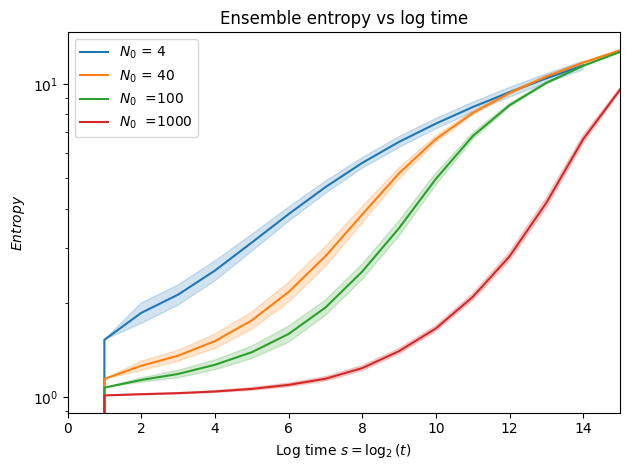

In [4]:
entropy_n4 = pd.read_pickle("data/entropy_df_s300_n4_t5k.pkl")
entropy_n40 = pd.read_pickle("data/entropy_df_s300_n40_t10k.pkl")
entropy_n100 = pd.read_pickle("data/entropy_df_s300_n100_t10k.pkl")
entropy_n1000 = pd.read_pickle("data/entropy_df_s300_n1000_t10k.pkl")

sns.lineplot(data=entropy_n4, x="measurement", y="value",errorbar="sd",label=r"$N_0$ = 4" )
sns.lineplot(data=entropy_n40, x="measurement", y="value",errorbar="sd",label=r"$N_0$ = 40" )
sns.lineplot(data=entropy_n100, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =100" )
sns.lineplot(data=entropy_n1000, x="measurement", y="value",errorbar="sd",label=r"$N_0$  =1000" )
plt.title("Ensemble entropy vs log time")
plt.ylabel("$Entropy$")
plt.xlabel(r"Log time $s = \log_2(t)$")
plt.xlim([0,15])
plt.yscale("log")
plt.tight_layout()
plt.show()

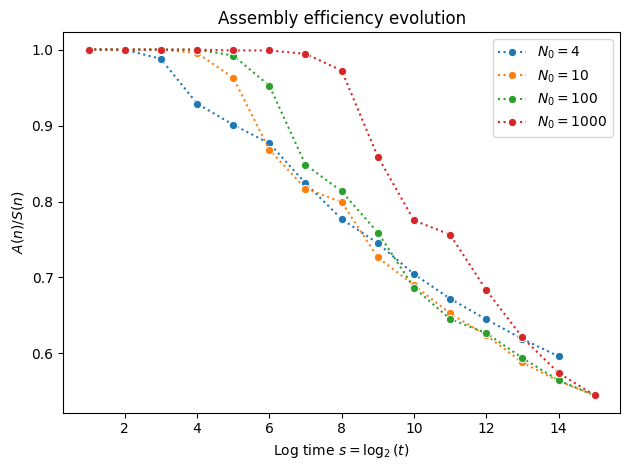

In [32]:
efficiency_4 = assembly_n4[steps_n4 > 0].value / steps_n4[steps_n4.value > 0 ].value
efficiency_40 = assembly_n40[steps_n40 > 0].value / steps_n40[steps_n40.value > 0 ].value
efficiency_100 = assembly_n100[steps_n100 > 0].value / steps_n100[steps_n100.value > 0 ].value
efficiency_1000 = assembly_n1000[steps_n1000 > 0].value / steps_n1000[steps_n1000.value > 0 ].value

mean_efficiency4 = np.zeros(16)
mean_efficiency40 = np.zeros(16)
mean_efficiency100 = np.zeros(16)
mean_efficiency1000 = np.zeros(16)

for i in range(16):
    mean_efficiency4[i] = np.mean(efficiency_4[300*i:300*(i+1)]) 
    mean_efficiency40[i] = np.mean(efficiency_40[300*i:300*(i+1)]) 
    mean_efficiency100[i] = np.mean(efficiency_100[300*i:300*(i+1)]) 
    mean_efficiency1000[i] = np.mean(efficiency_1000[300*i:300*(i+1)]) 


sns.lineplot(x = np.arange(16), y =mean_efficiency4,marker="o", linestyle=":", label=r"$N_0 = 4$")
sns.lineplot(x = np.arange(16), y =mean_efficiency40, marker = "o", linestyle=":", label=r"$N_0 = 10$")
sns.lineplot(x = np.arange(16), y =mean_efficiency100, marker = "o", linestyle = ":", label=r"$N_0 = 100$")
sns.lineplot(x = np.arange(16), y =mean_efficiency1000, marker = "o", linestyle = ":",label=r"$N_0 = 1000$")
plt.xlabel(r"Log time $s = \log_2(t)$")
plt.ylabel(r"$A(n)/S(n)$")
plt.title("Assembly efficiency evolution")
plt.tight_layout()
plt.show()


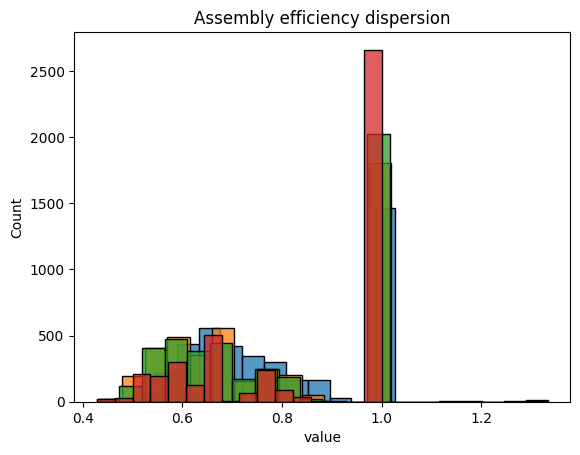

In [41]:
sns.histplot(efficiency_4,bins=20 )
sns.histplot(efficiency_40, bins=20)
sns.histplot(efficiency_100, bins=20)
sns.histplot(efficiency_1000, bins=16)
plt.title("Assembly efficiency dispersion")
plt.show()